# Unit 09｜主动学习综合演练

## Goal

在人工候选池用冻结配置运行 GP + Random/Greedy/UCB/EI，生成可审计研究包并准备公开论文复现。

本 Notebook 是确定性的人工教学实验，不是学习者已完成的研究，
也不是粘合剂实验结果。


## Setup

全部结果仅在内存中生成，不是公开数据基线。个人副本可将表保存到自己的 results/。


In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel

config = {
    "artifact_kind": "deterministic_synthetic_tutorial",
    "objective": "maximize",
    "n_initial": 4,
    "n_rounds": 8,
    "batch_size": 1,
    "run_seeds": [11, 22, 33, 44, 55],
    "strategies": ["random", "greedy", "ucb", "ei"],
    "beta": 1.2,
    "xi": 0.01,
}

x1 = np.linspace(0.0, 1.0, 8)
x2 = np.linspace(0.0, 1.0, 8)
grid_1, grid_2 = np.meshgrid(x1, x2)
X_all = np.column_stack([grid_1.ravel(), grid_2.ravel()])
oracle_values = (
    1.8 * np.sin(3.2 * X_all[:, 0])
    + 1.2 * np.cos(4.0 * X_all[:, 1])
    + 0.7 * X_all[:, 0] * X_all[:, 1]
)
candidate_ids = np.array([f"CAP{i:03d}" for i in range(len(X_all))])

def capstone_oracle(global_indices):
    indices = np.atleast_1d(global_indices).astype(int)
    values = oracle_values[indices].copy()
    return float(values[0]) if np.isscalar(global_indices) else values

print(json.dumps(config, ensure_ascii=False, indent=2))
print("候选数:", len(X_all), "数据类型: 人工教学候选池")


{
  "artifact_kind": "deterministic_synthetic_tutorial",
  "objective": "maximize",
  "n_initial": 4,
  "n_rounds": 8,
  "batch_size": 1,
  "run_seeds": [
    11,
    22,
    33,
    44,
    55
  ],
  "strategies": [
    "random",
    "greedy",
    "ucb",
    "ei"
  ],
  "beta": 1.2,
  "xi": 0.01
}
候选数: 64 数据类型: 人工教学候选池


## Steps

按顺序执行。每个变量第一次出现时，先确认它的类型、形状和标签权限。


### 1. 定义冻结模型和采集函数

同一 GP 用于所有策略；Random 也训练模型以记录可比预测，但不使用分数选点。


In [2]:
def make_gp():
    kernel = (
        ConstantKernel(1.0, constant_value_bounds="fixed")
        * RBF(0.35, length_scale_bounds="fixed")
        + WhiteKernel(0.02, noise_level_bounds="fixed")
    )
    return GaussianProcessRegressor(
        kernel=kernel,
        optimizer=None,
        normalize_y=True,
    )

def expected_improvement(mean, std, best_observed, xi):
    safe_std = np.maximum(std, 1e-12)
    improvement = mean - best_observed - xi
    z = improvement / safe_std
    result = (
        improvement * norm.cdf(z)
        + std * norm.pdf(z)
    )
    return np.where(
        std > 0,
        result,
        np.maximum(improvement, 0.0),
    )

def select_with_tie_break(score, ids):
    order = np.lexsort((ids.astype(str), -np.asarray(score)))
    return int(order[0])


### 2. 运行一条完整轨迹

逐轮日志保存 query 前字段；`observed_y` 在 ID 固定后加入。


In [3]:
def run_strategy(
    strategy,
    initial_indices,
    initial_values,
    run_seed,
    oracle,
):
    labeled = list(np.array(initial_indices, dtype=int))
    labeled_y = list(np.asarray(initial_values, dtype=float))
    pool = [
        index for index in range(len(X_all))
        if index not in labeled
    ]
    rng = np.random.default_rng(run_seed + 5000)
    records = []

    for round_number in range(1, config["n_rounds"] + 1):
        model = make_gp()
        model.fit(X_all[labeled], np.asarray(labeled_y))
        mean, std = model.predict(X_all[pool], return_std=True)

        if strategy == "random":
            score = np.full(len(pool), np.nan)
            query_local = int(rng.integers(len(pool)))
        elif strategy == "greedy":
            score = mean
            query_local = select_with_tie_break(
                score,
                candidate_ids[pool],
            )
        elif strategy == "ucb":
            score = mean + config["beta"] * std
            query_local = select_with_tie_break(
                score,
                candidate_ids[pool],
            )
        elif strategy == "ei":
            score = expected_improvement(
                mean,
                std,
                float(np.max(labeled_y)),
                config["xi"],
            )
            query_local = select_with_tie_break(
                score,
                candidate_ids[pool],
            )
        else:
            raise ValueError(strategy)

        query_global = int(pool[query_local])
        record = {
            "strategy": strategy,
            "run_seed": run_seed,
            "round": round_number,
            "candidate_id": candidate_ids[query_global],
            "prediction_mean": float(mean[query_local]),
            "prediction_std": float(std[query_local]),
            "acquisition_score": (
                float(score[query_local])
                if strategy != "random"
                else np.nan
            ),
            "model_version": "fixed_gp_rbf_v1",
        }

        # 标签揭示线
        observed_y = float(oracle(query_global))
        labeled.append(query_global)
        labeled_y.append(observed_y)
        pool.remove(query_global)
        best_so_far = float(np.max(labeled_y))
        record.update({
            "observed_y": observed_y,
            "n_labeled": len(labeled),
            "best_so_far": best_so_far,
        })
        records.append(record)
    return records


### 3. 运行冻结实验矩阵

每个种子的所有策略共享初始集，`.copy()` 避免相互修改。


In [4]:
records = []
for run_seed in config["run_seeds"]:
    initial_rng = np.random.default_rng(run_seed)
    initial_indices = initial_rng.choice(
        len(X_all),
        size=config["n_initial"],
        replace=False,
    )
    initial_values = capstone_oracle(initial_indices)
    for strategy in config["strategies"]:
        records.extend(
            run_strategy(
                strategy,
                initial_indices.copy(),
                initial_values.copy(),
                run_seed,
                capstone_oracle,
            )
        )
query_log = pd.DataFrame(records)
offline_global_best = float(oracle_values.max())
query_log["simple_regret"] = (
    offline_global_best - query_log["best_so_far"]
)
print(query_log.head(8).round(4).to_string(index=False))


strategy  run_seed  round candidate_id  prediction_mean  prediction_std  acquisition_score   model_version  observed_y  n_labeled  best_so_far  simple_regret
  random        11      1       CAP005           0.9891          0.3102                NaN fixed_gp_rbf_v1      2.5593          5       2.5593         0.4051
  random        11      2       CAP035           0.7682          0.6086                NaN fixed_gp_rbf_v1      1.1491          6       2.5593         0.4051
  random        11      3       CAP058           0.3979          0.2988                NaN fixed_gp_rbf_v1      0.8415          7       2.5593         0.4051
  random        11      4       CAP021           1.7478          0.3184                NaN fixed_gp_rbf_v1      2.0001          8       2.5593         0.4051
  random        11      5       CAP030           0.7412          0.1956                NaN fixed_gp_rbf_v1      0.7844          9       2.5593         0.4051
  random        11      6       CAP033           0.5

### 4. 从长表生成指标

指标表可以重新生成；不要手工修改以获得更好结论。


In [5]:
metrics = query_log.groupby(
    ["strategy", "round"], as_index=False
).agg(
    regret_mean=("simple_regret", "mean"),
    regret_std=("simple_regret", "std"),
    best_mean=("best_so_far", "mean"),
    n_runs=("run_seed", "nunique"),
)
final_metrics = metrics[
    metrics["round"] == config["n_rounds"]
].sort_values("regret_mean")
print(final_metrics.round(4).to_string(index=False))


strategy  round  regret_mean  regret_std  best_mean  n_runs
      ei      8       0.0000      0.0000     2.9643       5
  greedy      8       0.0000      0.0000     2.9643       5
     ucb      8       0.0000      0.0000     2.9643       5
  random      8       0.4216      0.3376     2.5427       5


### 5. 生成学习曲线和探索消融

Greedy 与 UCB/EI 的差异用于检查探索模块；曲线比最终单点更完整。


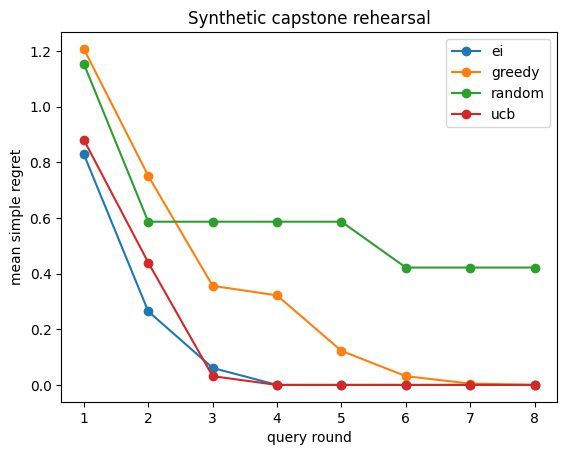

strategy  regret_mean  regret_std
      ei          0.0         0.0
  greedy          0.0         0.0
     ucb          0.0         0.0


In [6]:
for strategy, frame in metrics.groupby("strategy"):
    plt.plot(
        frame["round"],
        frame["regret_mean"],
        marker="o",
        label=strategy,
    )
plt.xlabel("query round")
plt.ylabel("mean simple regret")
plt.title("Synthetic capstone rehearsal")
plt.legend()
plt.show()

ablation_table = final_metrics[
    final_metrics["strategy"].isin(
        ["greedy", "ucb", "ei"]
    )
][["strategy", "regret_mean", "regret_std"]]
print(ablation_table.round(4).to_string(index=False))


### 6. 形成处理并列且边界正确的报告

最低值可能并列；报告必须引用人工候选池、固定协议、多种子和下一阶段。


In [7]:
best_regret = float(final_metrics["regret_mean"].min())
tied = final_metrics[
    np.isclose(
        final_metrics["regret_mean"],
        best_regret,
        rtol=0.0,
        atol=1e-12,
    )
]["strategy"].astype(str).tolist()
result_sentence = (
    f"最终平均 regret 最低的策略为 {tied[0]} "
    f"({best_regret:.3f})。"
    if len(tied) == 1
    else
    f"最终平均 regret 最低值为 {best_regret:.3f}，"
    f"{'、'.join(tied)} 并列；当前预算不能区分它们。"
)
report = "\n".join([
    "# 主动学习人工综合演练报告",
    (
        f"- 协议：人工候选池，{config['n_rounds']} 轮预算，"
        f"{len(config['run_seeds'])} 个预声明种子。"
    ),
    f"- 结果：{result_sentence}",
    "- 消融：比较 Greedy、UCB 与 EI，检查探索项是否带来差异。",
    (
        "- 负结果：若策略并列或复杂策略无优势，原样保留，"
        "不事后改种子或参数。"
    ),
    "- 限制：结果不代表公开材料基准或真实粘合剂性能。",
    "- 下一步：在 P01/P02 公开数据上按作者协议复现。",
])
print(report)


# 主动学习人工综合演练报告
- 协议：人工候选池，8 轮预算，5 个预声明种子。
- 结果：最终平均 regret 最低值为 0.000，ei、greedy、ucb 并列；当前预算不能区分它们。
- 消融：比较 Greedy、UCB 与 EI，检查探索项是否带来差异。
- 负结果：若策略并列或复杂策略无优势，原样保留，不事后改种子或参数。
- 限制：结果不代表公开材料基准或真实粘合剂性能。
- 下一步：在 P01/P02 公开数据上按作者协议复现。


## Checks

这些断言检查形状、预算和无重复等机械条件；通过断言不代表研究结论已经成立。


In [8]:
expected_rows = (
    len(config["run_seeds"])
    * len(config["strategies"])
    * config["n_rounds"]
)
assert len(query_log) == expected_rows
assert metrics["n_runs"].eq(len(config["run_seeds"])).all()
assert query_log.groupby(
    ["strategy", "run_seed"]
)["candidate_id"].nunique().eq(config["n_rounds"]).all()
required_query_fields = [
    "candidate_id",
    "prediction_mean",
    "prediction_std",
    "observed_y",
    "model_version",
]
assert query_log[required_query_fields].notna().all().all()
assert query_log.groupby(
    ["strategy", "run_seed"]
)["n_labeled"].max().eq(
    config["n_initial"] + config["n_rounds"]
).all()
assert (query_log["simple_regret"] >= -1e-12).all()
assert set(ablation_table["strategy"]) == {"greedy", "ucb", "ei"}
assert len(tied) >= 1
if len(tied) > 1:
    assert "并列" in report
assert "真实粘合剂性能" in report
print("Unit 09 checks passed.")


Unit 09 checks passed.


## Next Steps

在个人副本保存 config、query_log、metrics、图和报告，再选择 P01 或 P02 进入公开论文复现。
